# Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Upload dados

In [2]:
df_raw = pd.read_csv("../data/customers_info.csv")

In [3]:
df_raw.head()

,Unnamed: 0,customer_unique_id,total_value,quant_orders
0,0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1
1,1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1
2,2,0000f46a3911fa3c0805444483337064,86.22,1
3,3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1
4,4,0004aac84e0df4da2b147fca70cf8255,196.89,1


In [4]:
# retirando colunas que não serão aplicadas
df1 = df_raw.drop(columns=["Unnamed: 0"])

In [5]:
# features que serão utilizadas
features = df1[['total_value','quant_orders']]

In [6]:
features

,total_value,quant_orders
0,141.90,1
1,27.19,1
2,86.22,1
3,43.62,1
4,196.89,1
...,...,...
94978,2067.42,1
94979,84.58,1
94980,112.46,1
94981,133.69,1


In [12]:
# aplicação de mesma ordem de grandeza nas variáveis
standard_scaler = StandardScaler()
feature_scaled = standard_scaler.fit_transform(features)

In [15]:
# Aplicação de clusterização usando o modelo K-means
wcss = []
range_values = range(1, 20)
for i in range_values:
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(feature_scaled)
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

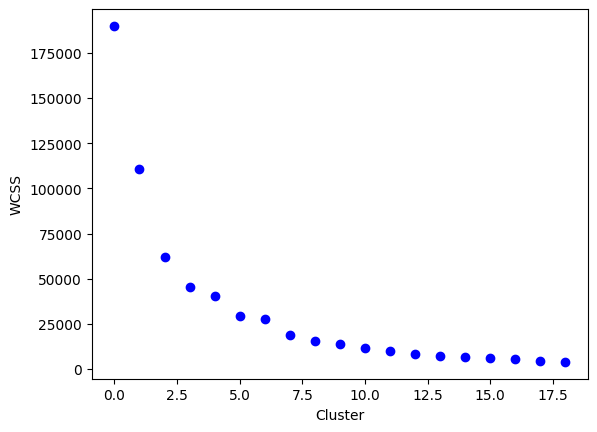

In [17]:
# visualização
plt.plot(wcss, 'bo')
plt.xlabel('Cluster')
plt.ylabel('WCSS')

In [ ]:
# aplicação de 4 clusters
kmeans = KMeans(n_clusters=4)
kmeans.fit(feature_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [20]:
df1["cluster"] = kmeans.labels_
df1

,customer_unique_id,total_value,quant_orders,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,0
2,0000f46a3911fa3c0805444483337064,86.22,1,0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,0
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,0
...,...,...,...,...
94978,fffcf5a5ff07b0908bd4e2dbc735a684,2067.42,1,2
94979,fffea47cd6d3cc0a88bd621562a9d061,84.58,1,0
94980,ffff371b4d645b6ecea244b27531430a,112.46,1,0
94981,ffff5962728ec6157033ef9805bacc48,133.69,1,0


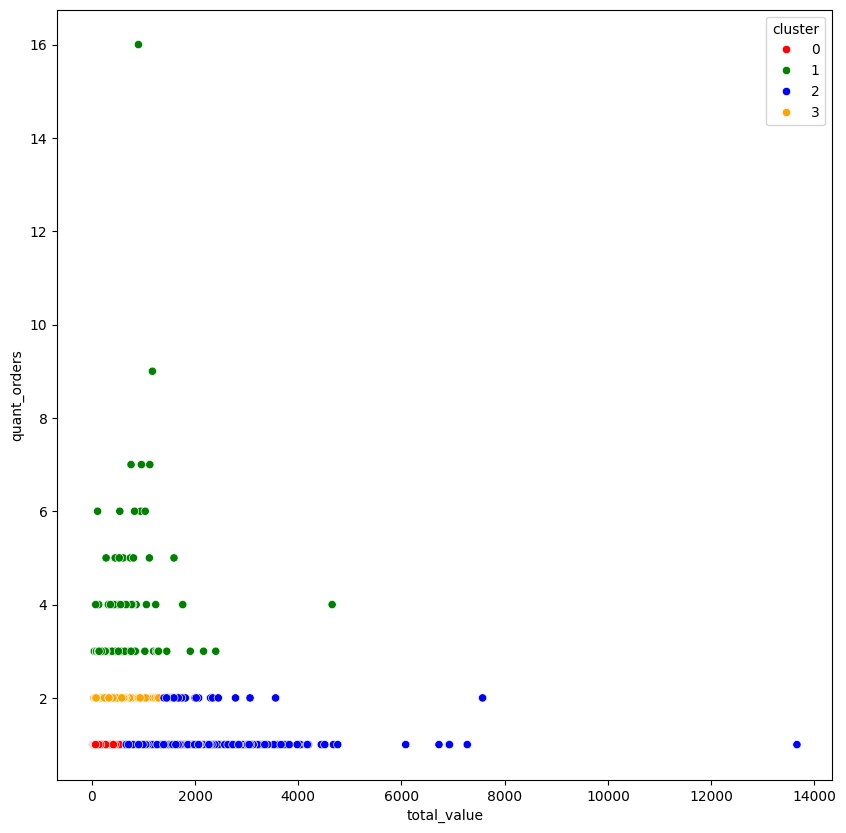

In [24]:
plt.figure(figsize=(10,10))
ax = sns.scatterplot(data=df1, x='total_value', y='quant_orders', hue='cluster', palette=['red','green','blue','orange'])
plt.show()